# Applied Data Science Lab - Experiment 06

**Class:** BE-Computer  
**Semester:** VIII  
**Subject:** Applied Data Science Lab

## AIM
Time series analysis and forecasting.

## Theory - Why Time Series Analysis and Forecasting Is Important
- To differentiate between random fluctuations and outliers.
- To separate genuine insights from seasonal variations.
- To understand how data changes over time.
- To identify the direction in which data is changing (trend).

## Method
- Select an appropriate dataset for time series forecasting.
- Data preparation for time series data:
  - Convert date column to datetime type and set it as index.
  - Decompose time series data to identify trend, seasonality, and residuals.
  - Plot AutoCorrelation Function (ACF).
  - Plot Partial AutoCorrelation Function (PACF).
- Perform Augmented Dickey-Fuller (ADF) test for stationarity.
- Time series forecasting models:
  - Linear Regression for forecasting.
  - Moving average smoothing model using Pandas rolling().
  - AutoRegressive Integrated Moving Average (ARIMA) model.
- Evaluation of models:
  1. Mean Absolute Error (MAE)
  2. Mean Absolute Percentage Error (MAPE)
  3. Mean Squared Error (MSE)
  4. Root Mean Squared Error (RMSE)

## Implementation Details
- **Dataset used:** Synthetic monthly sales time series generated in this notebook.
- **Libraries:**
  - `statsmodels.tsa.seasonal`
  - `statsmodels.tsa.stattools.acf`
  - `statsmodels.tsa.stattools.pacf`
  - `statsmodels.tsa.arima.model`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [2]:
np.random.seed(42)
n = 60                          # 60 months of data
time = pd.date_range(start="2019-01", periods=n, freq="MS")

trend     = np.linspace(100, 200, n)          # gradual upward trend
seasonal  = 20 * np.sin(2 * np.pi * np.arange(n) / 12)  # yearly cycle
noise     = np.random.normal(0, 10, n)        # random fluctuations
sales     = trend + seasonal + noise

ts = pd.Series(sales, index=time, name="Monthly Sales")

print("=== Dataset Preview ===")
print(ts.head(10))

=== Dataset Preview ===
2019-01-01    104.967142
2019-02-01    110.312272
2019-03-01    127.187224
2019-04-01    140.315044
2019-05-01    121.758635
2019-06-01    116.133207
2019-07-01    125.961620
2019-08-01    109.538754
2019-09-01     91.544070
2019-10-01    100.679838
Freq: MS, Name: Monthly Sales, dtype: float64


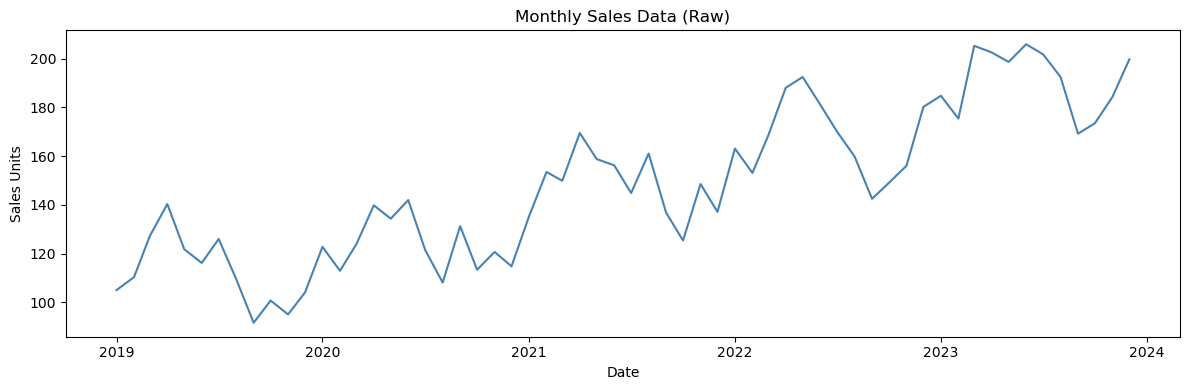

In [3]:
# ============================================================
# STEP 2 — Visualise the Raw Data
# ============================================================
plt.figure(figsize=(12, 4))
plt.plot(ts, color="steelblue", linewidth=1.5)
plt.title("Monthly Sales Data (Raw)")
plt.xlabel("Date")
plt.ylabel("Sales Units")
plt.tight_layout()
plt.savefig("01_raw_data.png", dpi=150)
plt.show()

In [4]:
# ============================================================
# STEP 3 — Check Stationarity (ADF Test)
# ============================================================
# ARIMA requires the series to be STATIONARY — meaning its
# statistical properties (mean, variance) don't change over time.
# We use the Augmented Dickey-Fuller (ADF) test:
#   H0 (null hypothesis): Series has a unit root → NOT stationary
#   If p-value < 0.05 → reject H0 → series IS stationary

def adf_test(series, name="Series"):
    result = adfuller(series.dropna())
    print(f"\n=== ADF Test: {name} ===")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Conclusion    : {'STATIONARY ✓' if result[1] < 0.05 else 'NOT stationary ✗'}")

adf_test(ts, "Raw Sales")


=== ADF Test: Raw Sales ===
  ADF Statistic : 0.9871
  p-value       : 0.9941
  Conclusion    : NOT stationary ✗



=== ADF Test: Differenced Sales ===
  ADF Statistic : -6.9810
  p-value       : 0.0000
  Conclusion    : STATIONARY ✓


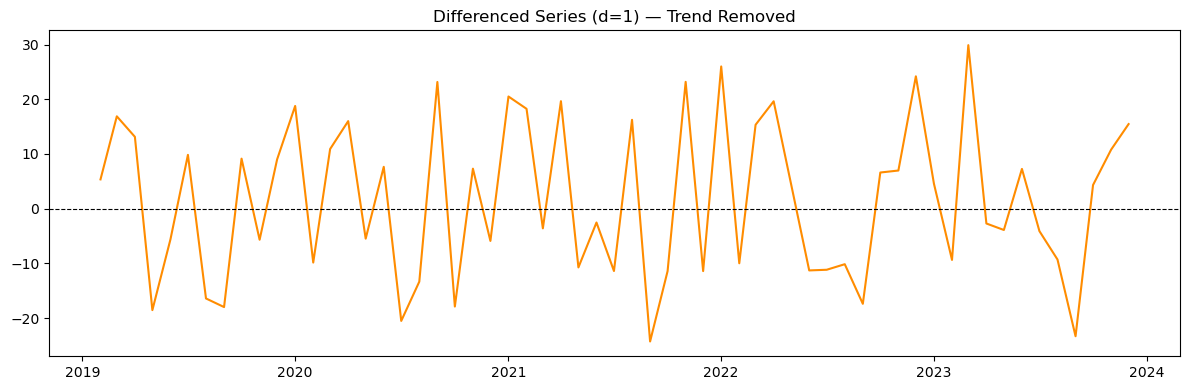

In [5]:
# ============================================================
# STEP 4 — Make the Series Stationary (Differencing)
# ============================================================
# If NOT stationary → we apply differencing.
# First-order differencing: new_value = value[t] - value[t-1]
# This removes the trend. The number of times we difference = d in ARIMA.

ts_diff = ts.diff().dropna()    # d = 1 (first difference)
adf_test(ts_diff, "Differenced Sales")

plt.figure(figsize=(12, 4))
plt.plot(ts_diff, color="darkorange", linewidth=1.5)
plt.title("Differenced Series (d=1) — Trend Removed")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig("02_differenced.png", dpi=150)
plt.show()

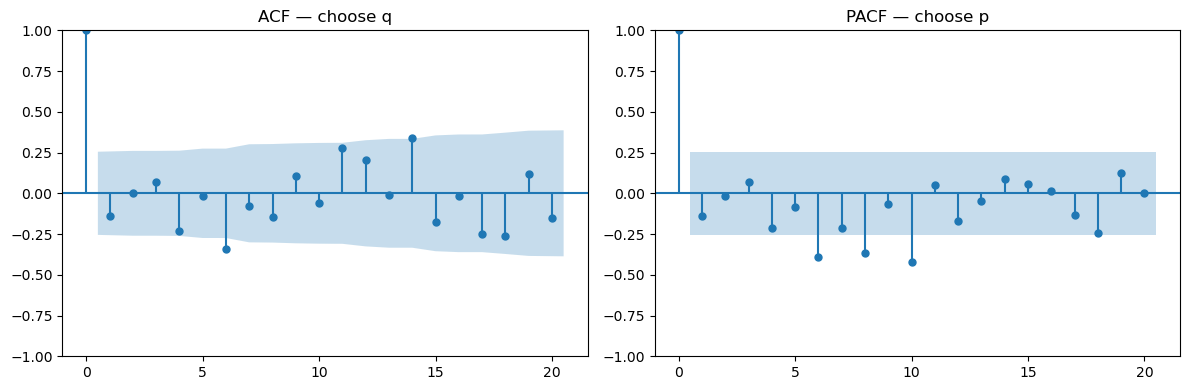

In [6]:
# ============================================================
# STEP 5 — Determine p and q Using ACF / PACF Plots
# ============================================================
# ACF  (Autocorrelation Function)     → tells us q (MA order)
#       Cut-off after lag q → use that value
# PACF (Partial Autocorrelation Function) → tells us p (AR order)
#       Cut-off after lag p → use that value

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts_diff,  ax=axes[0], lags=20, title="ACF — choose q")
plot_pacf(ts_diff, ax=axes[1], lags=20, title="PACF — choose p")
plt.tight_layout()
plt.savefig("03_acf_pacf.png", dpi=150)
plt.show()

# From the plots we read approximate values. Here we use p=2, d=1, q=2.
p, d, q = 2, 1, 2

In [7]:
# ============================================================
# STEP 6 — Split Data into Train / Test
# ============================================================
# We keep the last 12 months as the "future" we want to predict.
split      = int(len(ts) * 0.80)   # 80% train, 20% test
train, test = ts[:split], ts[split:]

print(f"\nTrain size: {len(train)} | Test size: {len(test)}")


Train size: 48 | Test size: 12


In [8]:
# ============================================================
# STEP 7 — Fit the ARIMA Model
# ============================================================
# ARIMA(p, d, q):
#   p = 2 → use last 2 values (autoregressive part)
#   d = 1 → difference once (integration part)
#   q = 2 → use last 2 forecast errors (moving average part)

model  = ARIMA(train, order=(p, d, q))
result = model.fit()

print("\n=== ARIMA Model Summary ===")
print(result.summary())


=== ARIMA Model Summary ===
                               SARIMAX Results                                
Dep. Variable:          Monthly Sales   No. Observations:                   48
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -186.548
Date:                Fri, 10 Apr 2026   AIC                            383.096
Time:                        09:01:53   BIC                            392.347
Sample:                    01-01-2019   HQIC                           386.577
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6145      0.165      9.784      0.000       1.291       1.938
ar.L2         -0.8644      0.125     -6.940      0.000      -1.108      -0.620
ma.L1         -1.8684  

In [9]:
# ============================================================
# STEP 8 — Forecast and Evaluate
# ============================================================
steps    = len(test)
forecast = result.forecast(steps=steps)

# Evaluation Metrics
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100

print(f"\n=== Evaluation Metrics ===")
print(f"  MAE  (Mean Absolute Error)       : {mae:.2f}")
print(f"  RMSE (Root Mean Squared Error)   : {rmse:.2f}")
print(f"  MAPE (Mean Abs Percentage Error) : {mape:.2f}%")


=== Evaluation Metrics ===
  MAE  (Mean Absolute Error)       : 13.99
  RMSE (Root Mean Squared Error)   : 16.59
  MAPE (Mean Abs Percentage Error) : 7.11%


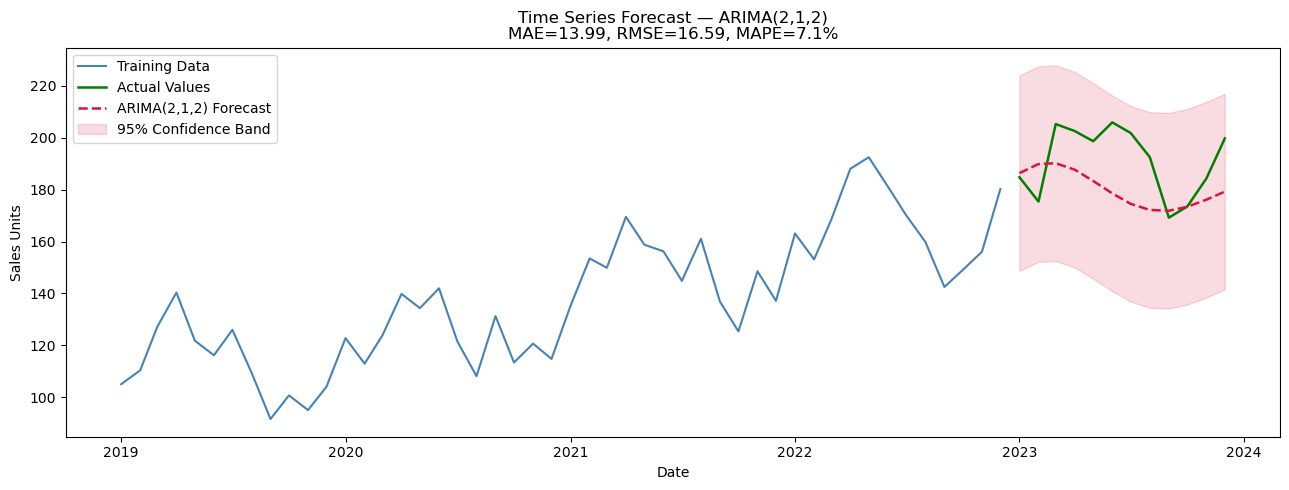

In [10]:
# ============================================================
# STEP 9 — Plot Forecast vs Actual
# ============================================================
plt.figure(figsize=(13, 5))
plt.plot(train, label="Training Data",  color="steelblue",  linewidth=1.5)
plt.plot(test,  label="Actual Values",  color="green",       linewidth=1.8)
plt.plot(forecast, label=f"ARIMA({p},{d},{q}) Forecast",
         color="crimson", linewidth=1.8, linestyle="--")

# Confidence interval (±1.96 * std of residuals ≈ 95%)
std_err = result.resid.std()
plt.fill_between(forecast.index,
                 forecast - 1.96 * std_err,
                 forecast + 1.96 * std_err,
                 color="crimson", alpha=0.15, label="95% Confidence Band")

plt.title(f"Time Series Forecast — ARIMA({p},{d},{q})\nMAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.1f}%")
plt.xlabel("Date")
plt.ylabel("Sales Units")
plt.legend()
plt.tight_layout()
plt.savefig("04_forecast.png", dpi=150)
plt.show()

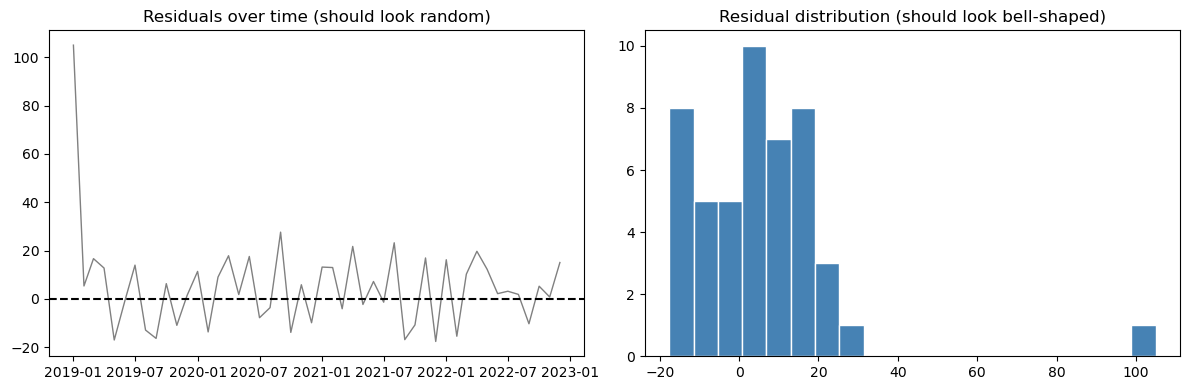

In [11]:
# ============================================================
# STEP 10 — Residual Diagnostics (Are errors just noise?)
# ============================================================
# Good model → residuals should look like white noise (no pattern)
residuals = result.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(residuals, color="gray", linewidth=1)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Residuals over time (should look random)")

axes[1].hist(residuals, bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Residual distribution (should look bell-shaped)")
plt.tight_layout()
plt.savefig("05_residuals.png", dpi=150)
plt.show()